In [83]:
#EJERCICIO 2
#PARTE A-------------------------------------------------------------------------------
#librerías que nos ayudaran a filtrar, ordenar, limpiar, hacer calculos estadísticos y graficarlos 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [84]:
ruta = r"/Users/nahuelvasquez/Documents/GitHub/BDyML---Grupo1-PRIVADO"

#cargamos las eph correspondientes 
eph_2024 = pd.read_excel(f"{ruta}/usu_individual_T124.xlsx")
eph_2025 = pd.read_excel(f"{ruta}/usu_individual_T125.xlsx")

# Verificamos dimensiones
print("EPH 2024 T1:", eph_2024.shape)
print("EPH 2025 T1:", eph_2025.shape)

EPH 2024 T1: (46050, 235)
EPH 2025 T1: (45425, 235)


In [85]:
#vemos las 5 primeras filas
eph_2024.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,1,1,1,1,40,N,25,140,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,1,1,1,43,S,34,648,...,0,0,0,0,5.0,5.0,5.0,NaN,5.0,4.0
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,1,2,1,43,S,34,648,...,0,0,0,0,5.0,5.0,5.0,NaN,5.0,4.0
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,1,1,1,1,40,N,19,281,...,0,0,0,0,9.0,10.0,NaN,10.0,9.0,10.0
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,1,1,1,1,40,S,23,252,...,0,0,0,0,7.0,9.0,7.0,NaN,8.0,8.0


In [86]:
#de las 235 variables filtramos las obligatorias del TP y adicionamos las nuestras "PP07H" Y "PP03I"
variables_seleccionadas = ["CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "PONDERA", "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", 
                "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR", "PP04C", "PP04D_COD", "P21", "P47T", "PP07H", "PP03I"]
#filtramos por año y lo guardamos en 2 dataframes 
df_2024 = eph_2024[variables_seleccionadas].copy()
df_2025 = eph_2025[variables_seleccionadas].copy()

#vemos las dimensiones finales
print("Dimensiones finales")
print("2024:", df_2024.shape)
print("2025:", df_2025.shape)

Dimensiones finales
2024: (46050, 20)
2025: (45425, 20)


In [87]:
#PARTE B-------------------------------------------------------------------------
#para proceder con la armonización entre años,
#comparamos los tipos de datos de cada variable entre 2024 y 2025

tipos = pd.DataFrame({"Tipo_2024": df_2024.dtypes, "Tipo_2025": df_2025.dtypes})

# Marcamos las variables donde el tipo es distinto entre años
tipos["Coinciden"] = tipos["Tipo_2024"] == tipos["Tipo_2025"]

print(tipos)

          Tipo_2024 Tipo_2025  Coinciden
CODUSU       object    object       True
ANO4          int64     int64       True
TRIMESTRE     int64     int64       True
NRO_HOGAR     int64     int64       True
PONDERA       int64     int64       True
CH04          int64     int64       True
CH06          int64     int64       True
CH07          int64     int64       True
CH08          int64   float64      False
NIVEL_ED      int64     int64       True
ESTADO        int64     int64       True
CAT_OCUP      int64     int64       True
EMPLEO      float64   float64       True
SECTOR      float64   float64       True
PP04C       float64   float64       True
PP04D_COD   float64   float64       True
P21           int64     int64       True
P47T        float64   float64       True
PP07H       float64   float64       True
PP03I       float64   float64       True


In [88]:
#pandas nos muestra los 3 tipos de datos "object" "int64" y "float64".

#object generalmente es texto
#int64 es un numero entero
#float64 puede ser un numero decimal o NaN

# Convertimos CH08 a entero nullable en ambos años
# Int64 (con mayúscula) tolera NaN, int64 común no
df_2024["CH08"] = df_2024["CH08"].astype("Int64")
df_2025["CH08"] = df_2025["CH08"].astype("Int64")

# Verificamos que ahora coinciden
print("Tipo CH08 en 2024:", df_2024["CH08"].dtype)
print("Tipo CH08 en 2025:", df_2025["CH08"].dtype)

tipos_post = pd.DataFrame({"Tipo_2024": df_2024.dtypes, "Tipo_2025": df_2025.dtypes})

tipos_post["Coinciden_post"] = tipos_post["Tipo_2024"] == tipos_post["Tipo_2025"]

Tipo CH08 en 2024: Int64
Tipo CH08 en 2025: Int64


In [89]:
#Verifico que se haya realizado el cambio de formato en la variable CH08
print(tipos_post)

          Tipo_2024 Tipo_2025  Coinciden_post
CODUSU       object    object            True
ANO4          int64     int64            True
TRIMESTRE     int64     int64            True
NRO_HOGAR     int64     int64            True
PONDERA       int64     int64            True
CH04          int64     int64            True
CH06          int64     int64            True
CH07          int64     int64            True
CH08          Int64     Int64            True
NIVEL_ED      int64     int64            True
ESTADO        int64     int64            True
CAT_OCUP      int64     int64            True
EMPLEO      float64   float64            True
SECTOR      float64   float64            True
PP04C       float64   float64            True
PP04D_COD   float64   float64            True
P21           int64     int64            True
P47T        float64   float64            True
PP07H       float64   float64            True
PP03I       float64   float64            True


In [90]:
#revisamos valores mínimos de las variables de ingreso
#un ingreso negativo no tiene sentido económico
print("Ingresos P21")
print("Mín 2024:", df_2024["P21"].min())
print("Mín 2025:", df_2025["P21"].min())

print("Ingresos P47T")
print("Mín 2024:", df_2024["P47T"].min())
print("Mín 2025:", df_2025["P47T"].min())


Ingresos P21
Mín 2024: -9
Mín 2025: -9
Ingresos P47T
Mín 2024: -9.0
Mín 2025: -9.0


In [91]:
# Reemplazamos -9 por NaN en las variables de ingreso
# En ambos años y ambas variables
for df in [df_2024, df_2025]:
    df["P21"]  = df["P21"].replace(-9, np.nan)
    df["P47T"] = df["P47T"].replace(-9, np.nan)

# Verificamos que ya no hay negativos

print("Mín P21  2024:", df_2024["P21"].min())
print("Mín P21  2025:", df_2025["P21"].min())
print("Mín P47T 2024:", df_2024["P47T"].min())
print("Mín P47T 2025:", df_2025["P47T"].min())

Mín P21  2024: 0.0
Mín P21  2025: 0.0
Mín P47T 2024: 0.0
Mín P47T 2025: 0.0


In [92]:
#PARTE C---------------------------------------------------------

import seaborn as sns

# Calculamos el porcentaje de nulos por variable en cada año
nulos_2024 = df_2024.isnull().mean() * 100
nulos_2025 = df_2025.isnull().mean() * 100

# Armamos una tabla con los dos años como columnas
df_nulos = pd.DataFrame({
    f"2024 T1(n={len(df_2024)})": nulos_2024,
    f"2025 T1(n={len(df_2025)})": nulos_2025
})


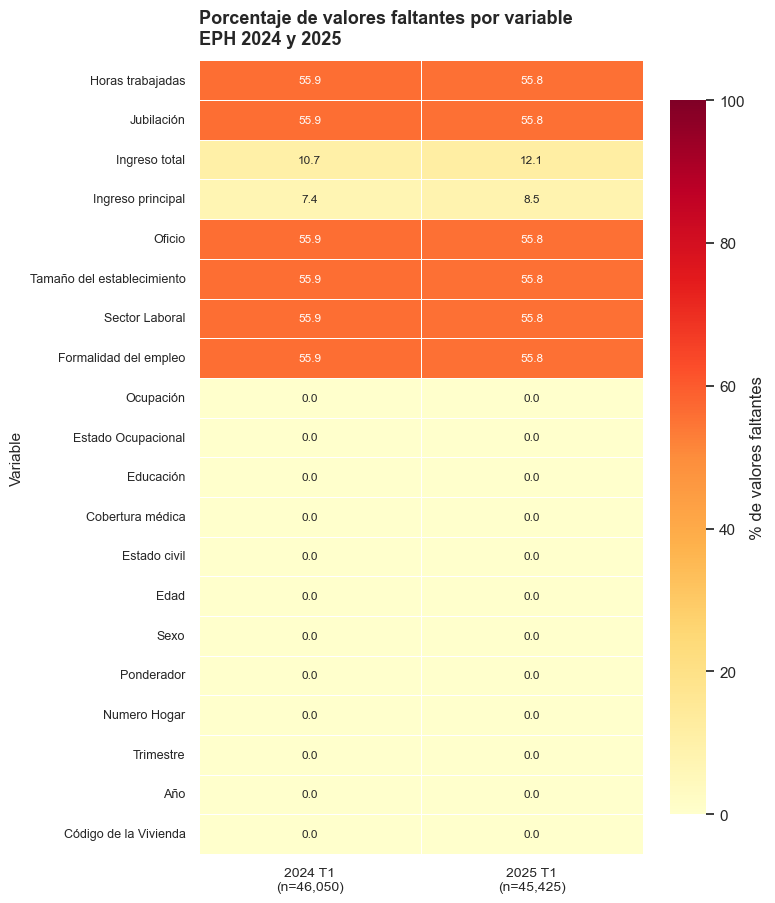

In [93]:
import seaborn as sns

nulos_2024 = df_2024.isnull().mean() * 100
nulos_2025 = df_2025.isnull().mean() * 100

df_nulos = pd.DataFrame({
    f"2024 T1\n(n={len(df_2024):,})": nulos_2024,
    f"2025 T1\n(n={len(df_2025):,})": nulos_2025
})

# Diccionario para cambiar los nombres técnicos por nombres más claros
glosario_resumido = {
    "CODUSU": "Código de la Vivienda",
    "ANO4": "Año",
    "TRIMESTRE": "Trimestre",
    "NRO_HOGAR": "Numero Hogar",
    "PONDERA": "Ponderador",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado civil",
    "CH08": "Cobertura médica",
    "NIVEL_ED": "Educación",
    "ESTADO": "Estado Ocupacional",
    "CAT_OCUP": "Ocupación",
    "EMPLEO": "Formalidad del empleo",
    "SECTOR": "Sector Laboral",
    "PP04C": "Tamaño del establecimiento",
    "PP04D_COD": "Oficio",
    "P21": "Ingreso principal",
    "P47T": "Ingreso total",
    "PP07H": "Jubilación",
    "PP03I": "Horas trabajadas"
}

# Cambiamos las etiquetas de las filas
df_nulos = df_nulos.rename(index=glosario_resumido)

# Invertimos el orden de las filas
df_nulos = df_nulos.iloc[::-1]

fig, ax = plt.subplots(figsize=(7.8, 9.2))

sns.heatmap(
    df_nulos,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={"shrink": 0.9, "label": "% de valores faltantes"},
    annot_kws={"size": 8.5}
)

ax.set_title(
    "Porcentaje de valores faltantes por variable\nEPH 2024 y 2025",
    fontsize=13,
    fontweight="bold",
    pad=12,
    loc="left"
)
ax.set_xlabel("")
ax.set_ylabel("Variable", fontsize=11)

# Mejoramos legibilidad de etiquetas
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=9)

# Principios de Schwabish: eliminamos bordes innecesarios
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("heatmap_nulos.png", dpi=150, bbox_inches="tight")
plt.show()

In [94]:
import numpy as np

# ── CH04: Sexo ──────────────────────────────────────────────
df_2024["es_mujer"] = (df_2024["CH04"] == 2).astype(int)
df_2025["es_mujer"] = (df_2025["CH04"] == 2).astype(int)

# ── ESTADO: Condición de actividad ─────────────────────────
df_2024["es_ocupado"]    = (df_2024["ESTADO"] == 1).astype(int)
df_2024["es_desocupado"] = (df_2024["ESTADO"] == 2).astype(int)
df_2024["es_inactivo"]   = (df_2024["ESTADO"] == 3).astype(int)

df_2025["es_ocupado"]    = (df_2025["ESTADO"] == 1).astype(int)
df_2025["es_desocupado"] = (df_2025["ESTADO"] == 2).astype(int)
df_2025["es_inactivo"]   = (df_2025["ESTADO"] == 3).astype(int)

# ── CAT_OCUP: Categoría ocupacional ────────────────────────
df_2024["es_asalariado"]     = (df_2024["CAT_OCUP"] == 3).astype(int)
df_2024["es_cuentapropista"] = (df_2024["CAT_OCUP"] == 2).astype(int)
df_2024["es_Jefe"]         = (df_2024["CAT_OCUP"] == 1).astype(int)

df_2025["es_asalariado"]     = (df_2025["CAT_OCUP"] == 3).astype(int)
df_2025["es_cuentapropista"] = (df_2025["CAT_OCUP"] == 2).astype(int)
df_2025["es_Jefe"]         = (df_2025["CAT_OCUP"] == 1).astype(int)

# ── SECTOR: Formal / Informal ──────────────────────────────
df_2024["sector_informal"] = (df_2024["SECTOR"] == 2).astype(int)
df_2025["sector_informal"] = (df_2025["SECTOR"] == 2).astype(int)

# ── NIVEL_ED: Educación superior/universitaria ─────────────
df_2024["educacion_superior"] = df_2024["NIVEL_ED"].isin([5, 6]).astype(int)
df_2025["educacion_superior"] = df_2025["NIVEL_ED"].isin([5, 6]).astype(int)

# Verificación
print("Variables dummy creadas. Verificación:")
print(df_2024[[
    "CH04", "es_mujer",
    "ESTADO", "es_ocupado", "es_desocupado", "es_inactivo",
    "CAT_OCUP", "es_asalariado", "es_cuentapropista", "es_Jefe",
    "SECTOR", "sector_informal",
    "NIVEL_ED", "educacion_superior"
]].head(8))

Variables dummy creadas. Verificación:
   CH04  es_mujer  ESTADO  es_ocupado  es_desocupado  es_inactivo  CAT_OCUP  \
0     2         1       3           0              0            1         0   
1     1         0       1           1              0            0         2   
2     1         0       2           0              1            0         2   
3     2         1       3           0              0            1         0   
4     2         1       1           1              0            0         2   
5     1         0       1           1              0            0         3   
6     2         1       3           0              0            1         0   
7     1         0       3           0              0            1         0   

   es_asalariado  es_cuentapropista  es_Jefe  SECTOR  sector_informal  \
0              0                  0        0     NaN                0   
1              0                  1        0     2.0                1   
2              0              

In [95]:
# ── Factor de actualización ─────────────────────────────────
IPC_2024T1 = 4814.8   # IPC promedio 2024 T1
IPC_2025T1 = 8090.1   # IPC promedio 2025 T1

factor = IPC_2025T1 / IPC_2024T1
print(f"Factor de actualización: {factor:.4f}")
print(f"Inflación acumulada entre períodos: {(factor-1)*100:.1f}%")

# ── Actualizamos los ingresos de 2024 a pesos de 2025 ───────
# Solo actualizamos 2024 — 2025 ya está en pesos de 2025
df_2024["P21_real"]  = df_2024["P21"]  * factor
df_2024["P47T_real"] = df_2024["P47T"] * factor

# En 2025 las variables reales son iguales a las nominales
df_2025["P21_real"]  = df_2025["P21"]
df_2025["P47T_real"] = df_2025["P47T"]

# Verificamos — comparamos ingreso nominal vs real en 2024
print("\nComparación nominal vs real en 2024 (primeras 5 filas con ingreso):")
print(
    df_2024[["P21", "P21_real"]]
    .dropna()
    .head(5)
    .round(0)
    .to_string(index=False)
)

Factor de actualización: 1.6803
Inflación acumulada entre períodos: 68.0%

Comparación nominal vs real en 2024 (primeras 5 filas con ingreso):
     P21  P21_real
     0.0       0.0
150000.0  252039.0
     0.0       0.0
     0.0       0.0
250000.0  420064.0


In [96]:
#EJERCICIO 3 — Separar respondieron vs norespondieron
# Unimos ambos años en una sola base antes de separar
# Agregamos columna para identificar el año
df_2024["año"] = 2024
df_2025["año"] = 2025

df_total = pd.concat([df_2024, df_2025], ignore_index=True)
print(f"Base total combinada: {df_total.shape}")

# ESTADO = 0 significa que no respondieron
norespondieron = df_total[df_total["ESTADO"] == 0].copy()
respondieron   = df_total[df_total["ESTADO"] != 0].copy()

print(f"Respondieron:    {len(respondieron):,} personas")
print(f"No respondieron: {len(norespondieron):,} personas")
print(f"Porcentaje que no respondió: {len(norespondieron)/len(df_total)*100:.2f}%")

Base total combinada: (91475, 32)
Respondieron:    91,319 personas
No respondieron: 156 personas
Porcentaje que no respondió: 0.17%


In [97]:
#EJERCICIO 4
# Dentro de respondieron, nos quedamos solo con ESTADO = 1 (ocupados)
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print(f"Ocupados: {len(ocupados)} personas")
print(f"Porcentaje sobre respondieron: {len(ocupados)/len(respondieron)*100:.1f}%")

# Verificamos que no haya ningún ESTADO distinto de 1
print(f"Valores únicos de ESTADO en ocupados: {ocupados['ESTADO'].unique()}")

Ocupados: 40401 personas
Porcentaje sobre respondieron: 44.2%
Valores únicos de ESTADO en ocupados: [1]


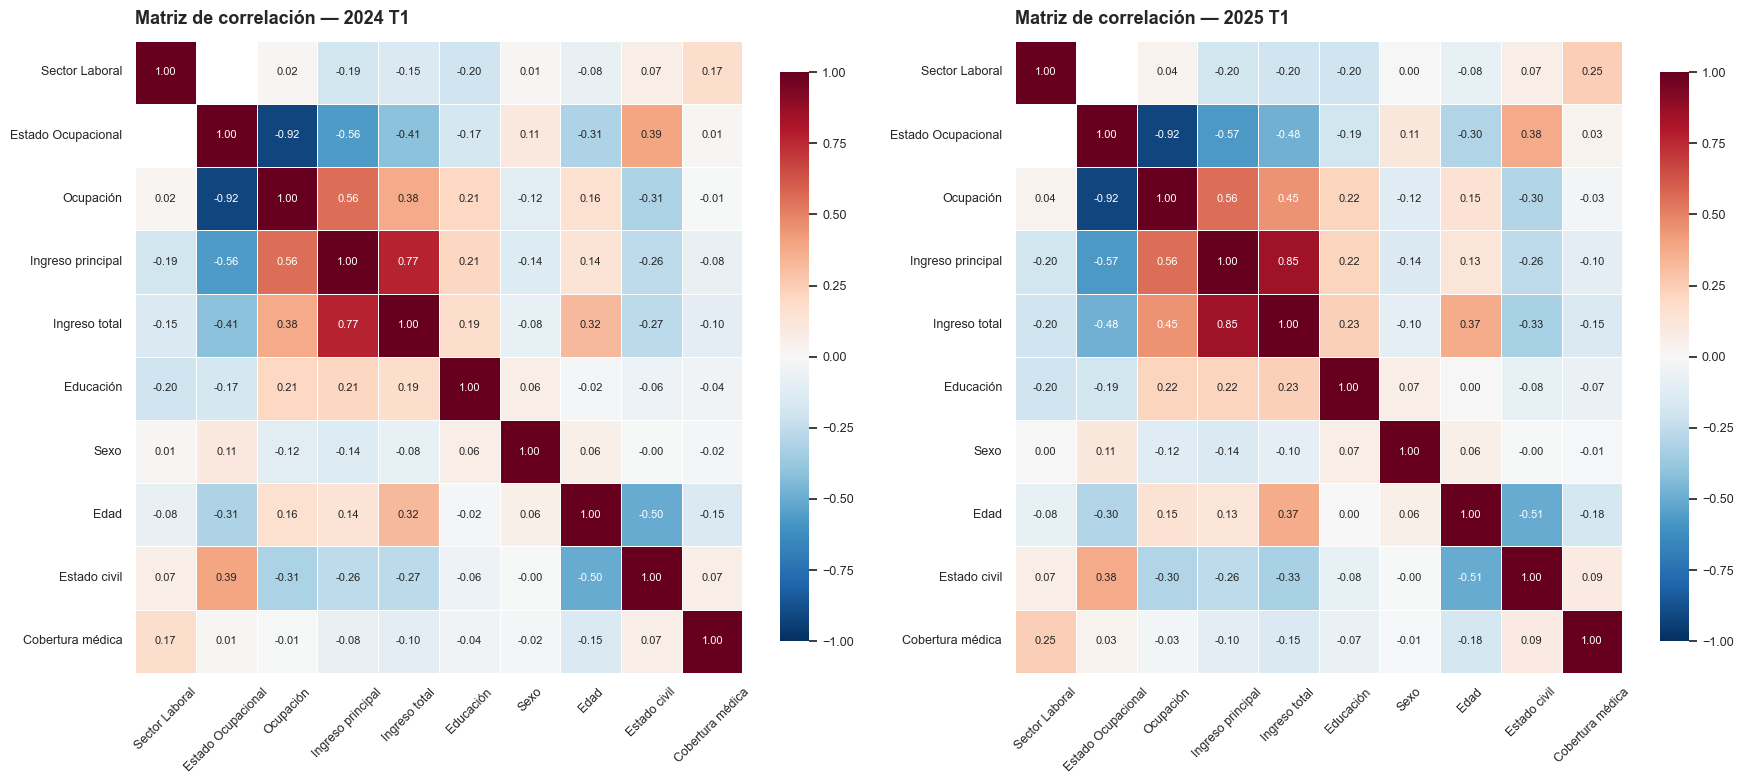

In [107]:
import seaborn as sns

# Variables para la matriz — las que pide el TP
vars_corr = ["SECTOR", "ESTADO", "CAT_OCUP", "P21_real", 
             "P47T_real", "NIVEL_ED", "CH04", "CH06", "CH07", "CH08"]

# Diccionario de nombres más claros para mostrar en el gráfico
rename_labels = {
    "CODUSU": "Código de la Vivienda",
    "ANO4": "Año",
    "TRIMESTRE": "Trimestre",
    "NRO_HOGAR": "Numero Hogar",
    "PONDERA": "Ponderador",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado civil",
    "CH08": "Cobertura médica",
    "NIVEL_ED": "Educación",
    "ESTADO": "Estado Ocupacional",
    "CAT_OCUP": "Ocupación",
    "EMPLEO": "Formalidad del empleo",
    "SECTOR": "Sector Laboral",
    "PP04C": "Tamaño del establecimiento",
    "PP04D_COD": "Oficio",
    "P21": "Ingreso principal",
    "P47T": "Ingreso total",
    "PP07H": "Jubilación",
    "PP03I": "Horas trabajadas",
    "P21_real": "Ingreso principal",
    "P47T_real": "Ingreso total"
}

# Calculamos correlaciones para cada año por separado
corr_2024 = respondieron[respondieron["año"] == 2024][vars_corr].corr()
corr_2025 = respondieron[respondieron["año"] == 2025][vars_corr].corr()

# Renombramos solo filas y columnas de la matriz
corr_2024 = corr_2024.rename(index=rename_labels, columns=rename_labels)
corr_2025 = corr_2025.rename(index=rename_labels, columns=rename_labels)

# Graficamos las dos matrices lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, corr, año in zip(axes, [corr_2024, corr_2025], ["2024 T1", "2025 T1"]):
    hm = sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",      # rojo = correlación negativa, azul = positiva
        center=0,           # blanco en 0
        vmin=-1, vmax=1,
        linewidths=0.4,
        linecolor="white",
        ax=ax,
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.9}
    )

    ax.set_title(
        f"Matriz de correlación — {año}",
        fontsize=13,
        fontweight="bold",
        pad=12,
        loc="left"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    # Mejoramos legibilidad de etiquetas
    ax.tick_params(axis="x", labelsize=9, rotation=45)
    ax.tick_params(axis="y", labelsize=9, rotation=0)

    # Eliminamos bordes innecesarios
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Limpiamos el contorno de la barra de color
    cbar = hm.collections[0].colorbar
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [100]:
# Definimos las variables para la tabla descriptiva
vars_desc = ["SECTOR", "ESTADO", "CAT_OCUP", "P21_real", "P47T_real",
             "NIVEL_ED", "CH04", "CH06", "CH07", "CH08",
             "PP04C", "PP04D_COD", "EMPLEO", "PP03I", "PP07H"]

desc = respondieron[vars_desc].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

desc.index = [
    "N (observaciones)",
    "Media",
    "Desvío Estándar",
    "Mínimo",
    "P1",
    "P25",
    "Mediana (P50)",
    "P75",
    "P99",
    "Máximo"
]

print(desc.round(2).to_string())

                     SECTOR    ESTADO  CAT_OCUP     P21_real    P47T_real  NIVEL_ED      CH04      CH06      CH07     CH08     PP04C  PP04D_COD    EMPLEO     PP03I     PP07H
N (observaciones)  40401.00  91319.00  91319.00     84077.00     81052.00  91319.00  91319.00  91319.00  91319.00  91318.0  40401.00   40401.00  40401.00  40401.00  40401.00
Media                  1.68      2.20      1.26    238323.08    394227.61      3.75      1.52     36.54      3.52     2.14     17.91   44947.10      1.44      1.87      1.01
Desvío Estándar        1.62      1.13      1.40    496451.77    657947.20      1.74      0.50     22.19      1.65      2.2     32.51   22947.59      0.56      0.47      0.73
Mínimo                 1.00      1.00      0.00         0.00         0.00      1.00      1.00     -1.00      1.00      1.0      0.00       1.00      1.00      1.00      0.00
P1                     1.00      1.00      0.00         0.00         0.00      1.00      1.00      1.00      1.00      1.0      0.

In [101]:
# Separamos por año
desc_2024 = respondieron[respondieron["año"]==2024][vars_desc].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)
desc_2025 = respondieron[respondieron["año"]==2025][vars_desc].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

# Renombramos índice en ambas
nuevos_indices = [
    "N (observaciones)", "Media", "Desvío Estándar",
    "Mínimo", "P1", "P25", "Mediana (P50)", "P75", "P99", "Máximo"
]
desc_2024.index = nuevos_indices
desc_2025.index = nuevos_indices

# Exportamos a Excel con dos hojas — una por año
with pd.ExcelWriter("estadistica_descriptiva.xlsx") as writer:
    desc_2024.round(2).to_excel(writer, sheet_name="2024 T1")
    desc_2025.round(2).to_excel(writer, sheet_name="2025 T1")

print("Tabla exportada a estadistica_descriptiva.xlsx")
print("\n=== 2024 T1 ===")
print(desc_2024.round(2).to_string())
print("\n=== 2025 T1 ===")
print(desc_2025.round(2).to_string())

Tabla exportada a estadistica_descriptiva.xlsx

=== 2024 T1 ===
                     SECTOR    ESTADO  CAT_OCUP     P21_real    P47T_real  NIVEL_ED      CH04      CH06      CH07     CH08     PP04C  PP04D_COD    EMPLEO     PP03I     PP07H
N (observaciones)  20325.00  45969.00  45969.00     42566.00     41107.00  45969.00  45969.00  45969.00  45969.00  45969.0  20325.00   20325.00  20325.00  20325.00  20325.00
Media                  1.66      2.21      1.27    199114.12    325849.74      3.75      1.52     36.29      3.52     2.14     18.14   45010.47      1.44      1.86      1.02
Desvío Estándar        1.60      1.14      1.40    409350.39    588728.58      1.75      0.50     22.22      1.65     2.37     32.65   22939.37      0.58      0.47      0.73
Mínimo                 1.00      1.00      0.00         0.00         0.00      1.00      1.00     -1.00      1.00      1.0      0.00       1.00      1.00      1.00      0.00
P1                     1.00      1.00      0.00         0.00      

In [102]:
# Cruzamos PP07H = 0 con CAT_OCUP para entender a quiénes corresponde
print("CAT_OCUP cuando PP07H = 0 (en 2024):")
print(df_2024[df_2024["PP07H"] == 0]["CAT_OCUP"].value_counts())

CAT_OCUP cuando PP07H = 0 (en 2024):
CAT_OCUP
2    4367
1     678
4      77
Name: count, dtype: int64


In [110]:
# ── Construimos el indicador de tipo de asalariado ───────────
def clasificar_asalariado(row):
    # Solo aplica a asalariados
    if row["CAT_OCUP"] != 3:
        return np.nan
    
    # Si no sabe/no responde jubilación → excluir
    if row["PP07H"] not in [1, 2]:
        return np.nan
    
    # Si tiene descuento jubilatorio → formal
    if row["PP07H"] == 1:
        return "Formal"
    
    # Si no tiene descuento jubilatorio → informal
    # chequeamos tamaño del establecimiento
    if row["PP04C"] == 99 or pd.isna(row["PP04C"]):
        return np.nan
    elif row["PP04C"] >= 6:
        return "Upper-tier informal"
    else:
        return "Lower-tier informal"

ocupados["tipo_asalariado"] = ocupados.apply(
    clasificar_asalariado, axis=1
)

# Verificamos
print("Distribución del indicador:")
print(ocupados["tipo_asalariado"].value_counts(dropna=False))

# Solo entre asalariados
asalariados = ocupados[ocupados["CAT_OCUP"] == 3]
total_asal = len(asalariados)
upper_tier = (ocupados["tipo_asalariado"] == "Upper-tier informal").sum()

print(f"\nAsalariados totales: {total_asal:,}")
print(f"Upper-tier informales: {upper_tier:,}")
print(f"Porcentaje: {upper_tier/total_asal*100:.1f}%")

Distribución del indicador:
tipo_asalariado
Formal                 18934
NaN                    12309
Lower-tier informal     5943
Upper-tier informal     3215
Name: count, dtype: int64

Asalariados totales: 29,830
Upper-tier informales: 3,215
Porcentaje: 10.8%


In [111]:
# ── Tabla doble entrada: formal/informal por sexo y año ──────

# Trabajamos solo con asalariados de interés
asal = ocupados[ocupados["CAT_OCUP"] == 3].copy()
asal = asal[asal["tipo_asalariado"].isin(["Formal", "Upper-tier informal"])].copy()

# Etiquetas legibles
asal["condicion"] = asal["tipo_asalariado"]
asal["sexo"] = asal["CH04"].map({1: "Varones", 2: "Mujeres"})

# Función para calcular tabla por grupo
def tabla_informalidad(df, nombre):
    total = len(df)
    informal = (df["tipo_asalariado"] == "Upper-tier informal").sum()
    formal   = (df["tipo_asalariado"] == "Formal").sum()
    return {
        "Grupo": nombre,
        "Total": total,
        "Upper-tier informal (%)": round(informal/total*100, 1),
        "Formal (%)":              round(formal/total*100, 1)
    }

# Calculamos para cada año y grupo
resultados = []
for año in [2024, 2025]:
    sub = asal[asal["año"] == año]
    resultados.append(tabla_informalidad(sub, f"Total — {año}"))
    resultados.append(tabla_informalidad(sub[sub["CH04"] == 2], f"Mujeres — {año}"))
    resultados.append(tabla_informalidad(sub[sub["CH04"] == 1], f"Varones — {año}"))

tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))

# Exportamos
tabla.to_excel("tabla_informalidad.xlsx", index=False)
print("\nTabla exportada a tabla_informalidad.xlsx")

         Grupo  Total  Upper-tier informal (%)  Formal (%)
  Total — 2024  11328                     15.0        85.0
Mujeres — 2024   5076                     14.7        85.3
Varones — 2024   6252                     15.3        84.7
  Total — 2025  10821                     14.0        86.0
Mujeres — 2025   4810                     13.0        87.0
Varones — 2025   6011                     14.8        85.2

Tabla exportada a tabla_informalidad.xlsx


In [112]:
# Recreamos asal — asalariados con indicador de informalidad definido
asal = ocupados[ocupados["CAT_OCUP"] == 3].copy()
asal = asal[asal["tipo_asalariado"].isin(["Formal", "Upper-tier informal"])].copy()

# Etiquetas legibles
asal["condicion"] = asal["tipo_asalariado"]
asal["sexo"] = asal["CH04"].map({1: "Varones", 2: "Mujeres"})

print(f"Asalariados con indicador definido: {len(asal):,}")
print(f"Formales: {(asal['tipo_asalariado']=='Formal').sum():,}")
print(f"Upper-tier informales: {(asal['tipo_asalariado']=='Upper-tier informal').sum():,}")

Asalariados con indicador definido: 22,149
Formales: 18,934
Upper-tier informales: 3,215


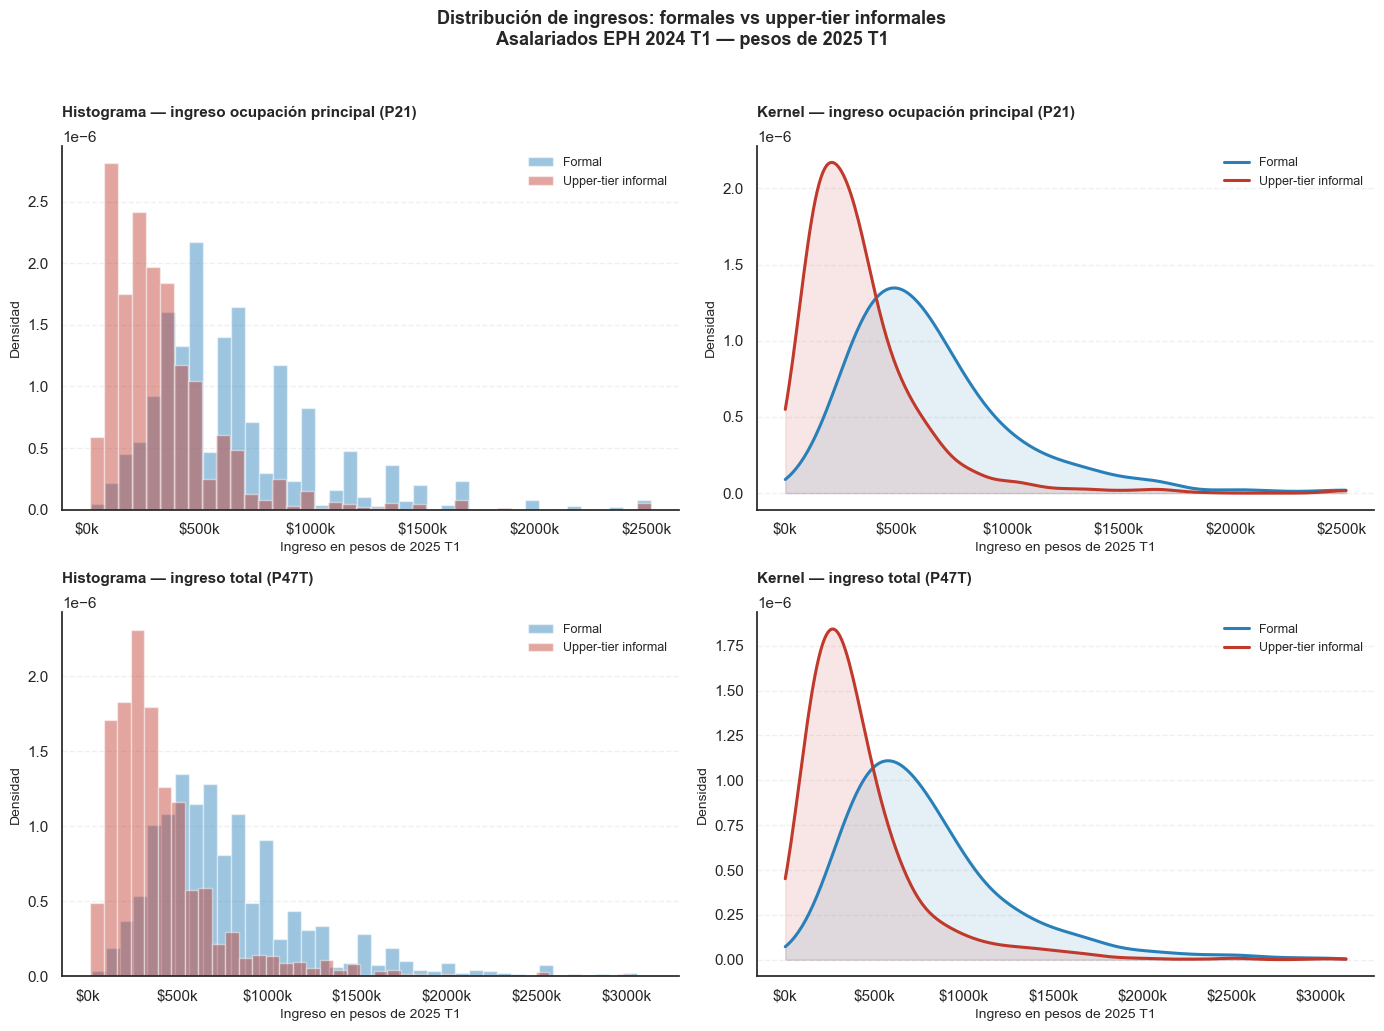

In [113]:
from scipy.stats import gaussian_kde

# Preparamos los datos — trabajamos con asalariados del año 2024
# con ingreso positivo (excluimos ceros y nulos)
asal_2024 = asal[asal["año"] == 2024].copy()

formales = asal_2024[
    (asal_2024["tipo_asalariado"] == "Formal") &
    (asal_2024["P21_real"] > 0)
]["P21_real"].dropna()

informales = asal_2024[
    (asal_2024["tipo_asalariado"] == "Upper-tier informal") &
    (asal_2024["P21_real"] > 0)
]["P21_real"].dropna()

formales_p47 = asal_2024[
    (asal_2024["tipo_asalariado"] == "Formal") &
    (asal_2024["P47T_real"] > 0)
]["P47T_real"].dropna()

informales_p47 = asal_2024[
    (asal_2024["tipo_asalariado"] == "Upper-tier informal") &
    (asal_2024["P47T_real"] > 0)
]["P47T_real"].dropna()

# Límite superior para cortar outliers extremos
# Usamos el percentil 99 para no distorsionar el gráfico
lim_p21 = asal_2024["P21_real"].quantile(0.99)
lim_p47 = asal_2024["P47T_real"].quantile(0.99)

# ── Gráfico de 4 paneles ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))

color_formal = "#2980B9"   # azul
color_informal = "#C0392B"   # rojo
alpha = 0.45

# ── Panel 1: Histograma P21 ──────────────────────────────────
ax = axes[0, 0]
ax.hist(formales[formales <= lim_p21],
        bins=40, color=color_formal,
        alpha=alpha, label="Formal", density=True)
ax.hist(informales[informales <= lim_p21],
        bins=40, color=color_informal,
        alpha=alpha, label="Upper-tier informal", density=True)
ax.set_title("Histograma — ingreso ocupación principal (P21)",
             fontsize=11, fontweight="bold", loc="left", pad=10)
ax.set_xlabel("Ingreso en pesos de 2025 T1", fontsize=10)
ax.set_ylabel("Densidad", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ── Panel 2: Kernel P21 ──────────────────────────────────────
ax = axes[0, 1]
for datos, color, label in [
    (formales[formales <= lim_p21], color_formal, "Formal"),
    (informales[informales <= lim_p21], color_informal, "Upper-tier informal")
]:
    kde = gaussian_kde(datos, bw_method=0.3)
    x = np.linspace(0, lim_p21, 300)
    ax.plot(x, kde(x), color=color, linewidth=2.2, label=label)
    ax.fill_between(x, kde(x), alpha=0.12, color=color)

ax.set_title("Kernel — ingreso ocupación principal (P21)",
             fontsize=11, fontweight="bold", loc="left", pad=10)
ax.set_xlabel("Ingreso en pesos de 2025 T1", fontsize=10)
ax.set_ylabel("Densidad", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ── Panel 3: Histograma P47T ─────────────────────────────────
ax = axes[1, 0]
ax.hist(formales_p47[formales_p47 <= lim_p47],
        bins=40, color=color_formal,
        alpha=alpha, label="Formal", density=True)
ax.hist(informales_p47[informales_p47 <= lim_p47],
        bins=40, color=color_informal,
        alpha=alpha, label="Upper-tier informal", density=True)
ax.set_title("Histograma — ingreso total (P47T)",
             fontsize=11, fontweight="bold", loc="left", pad=10)
ax.set_xlabel("Ingreso en pesos de 2025 T1", fontsize=10)
ax.set_ylabel("Densidad", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ── Panel 4: Kernel P47T ─────────────────────────────────────
ax = axes[1, 1]
for datos, color, label in [
    (formales_p47[formales_p47 <= lim_p47], color_formal, "Formal"),
    (informales_p47[informales_p47 <= lim_p47], color_informal, "Upper-tier informal")
]:
    kde = gaussian_kde(datos, bw_method=0.3)
    x = np.linspace(0, lim_p47, 300)
    ax.plot(x, kde(x), color=color, linewidth=2.2, label=label)
    ax.fill_between(x, kde(x), alpha=0.12, color=color)

ax.set_title("Kernel — ingreso total (P47T)",
             fontsize=11, fontweight="bold", loc="left", pad=10)
ax.set_xlabel("Ingreso en pesos de 2025 T1", fontsize=10)
ax.set_ylabel("Densidad", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Título general
fig.suptitle(
    "Distribución de ingresos: formales vs upper-tier informales\n"
    "Asalariados EPH 2024 T1 — pesos de 2025 T1",
    fontsize=13, fontweight="bold", y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("distribucion_ingresos.png", dpi=150, bbox_inches="tight")
plt.show()